In [1]:
# ============================================================
# CELL 2 - IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import os
import shutil
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from ultralytics import YOLO

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# CELL 3 - PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(r"C:\major-project")

MODEL_ROOT = PROJECT_ROOT / "model"

YOLO_ROOT = MODEL_ROOT / "yolo11"

YOLO_DATASET = MODEL_ROOT / "yolo11_dataset"

YOLO_RUNS = YOLO_ROOT / "runs"

YOLO_WEIGHTS = YOLO_ROOT / "weights"

NOTEBOOK_ROOT = MODEL_ROOT / "notebook"

print("Project root:")
print(PROJECT_ROOT)

print("\nYOLO root:")
print(YOLO_ROOT)

print("\nYOLO dataset:")
print(YOLO_DATASET)

print("\nPaths configured.")

Project root:
C:\major-project

YOLO root:
C:\major-project\model\yolo11

YOLO dataset:
C:\major-project\model\yolo11_dataset

Paths configured.


In [3]:
# ============================================================
# CELL 4 - CREATE YOLO DIRECTORIES
# ============================================================

directories = [
    YOLO_ROOT,
    YOLO_RUNS,
    YOLO_WEIGHTS,
    YOLO_DATASET,
    NOTEBOOK_ROOT,
]

for directory in directories:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Directories created successfully.")

for directory in directories:
    print(directory)

Directories created successfully.
C:\major-project\model\yolo11
C:\major-project\model\yolo11\runs
C:\major-project\model\yolo11\weights
C:\major-project\model\yolo11_dataset
C:\major-project\model\notebook


In [4]:
# ============================================================
# CELL 5 - VERIFY EXISTING DATASET
# ============================================================

existing_dataset = MODEL_ROOT / "dataset"

print("Existing dataset:")
print(existing_dataset)

print("\nExists:", existing_dataset.exists())

if existing_dataset.exists():

    print("\nContents:")

    for item in existing_dataset.iterdir():

        if item.is_dir():
            print("[DIR ]", item.name)

        else:
            print("[FILE]", item.name)

Existing dataset:
C:\major-project\model\dataset

Exists: True

Contents:
[DIR ] dataset
[DIR ] lifespan-dataset
[DIR ] test
[DIR ] train


In [5]:
# # ============================================================
# # CELL 6 - DOWNLOAD YOLO DETECTION DATASET
# # ============================================================

# import subprocess

# DATASET_REPO = "https://github.com/lightly-ai/dataset_fruits_detection.git"

# DOWNLOAD_LOCATION = MODEL_ROOT / "fruit_detection_source"

# if DOWNLOAD_LOCATION.exists():

#     print("Dataset repository already exists:")
#     print(DOWNLOAD_LOCATION)

# else:

#     print("Downloading dataset...")

#     result = subprocess.run(
#         [
#             "git",
#             "clone",
#             DATASET_REPO,
#             str(DOWNLOAD_LOCATION)
#         ],
#         capture_output=True,
#         text=True
#     )

#     print(result.stdout)

#     if result.returncode != 0:

#         print(result.stderr)

#         raise RuntimeError(
#             "Git clone failed. "
#             "Make sure Git is installed and network access is available."
#         )

# print("\nDataset downloaded successfully.")

In [6]:
# ============================================================
# CELL 7 - INSPECT DATASET
# ============================================================

source_dataset = MODEL_ROOT / "fruit_detection_source"

print("=" * 70)
print("DOWNLOADED DATASET")
print("=" * 70)

print("Path:")
print(source_dataset)

print("\nExists:")
print(source_dataset.exists())

if source_dataset.exists():

    for item in source_dataset.iterdir():

        if item.is_dir():
            print("[DIR ]", item.name)

        else:
            print("[FILE]", item.name)

DOWNLOADED DATASET
Path:
C:\major-project\model\fruit_detection_source

Exists:
True
[DIR ] .git
[FILE] data.yaml
[FILE] LICENSE
[FILE] README.md
[DIR ] test
[DIR ] train
[DIR ] valid


In [7]:
# ============================================================
# CELL 8 - FIND DATA YAML
# ============================================================

yaml_files = list(
    source_dataset.rglob("*.yaml")
)

yaml_files += list(
    source_dataset.rglob("*.yml")
)

print("YAML files found:")

for file in yaml_files:
    print(file)

if not yaml_files:

    raise FileNotFoundError(
        "No data.yaml found in the downloaded dataset."
    )

SOURCE_YAML = yaml_files[0]

print("\nUsing:")
print(SOURCE_YAML)

YAML files found:
C:\major-project\model\fruit_detection_source\data.yaml

Using:
C:\major-project\model\fruit_detection_source\data.yaml


In [8]:
# ============================================================
# CELL 9 - READ ORIGINAL DATA YAML
# ============================================================

with open(
    SOURCE_YAML,
    "r",
    encoding="utf-8"
) as f:

    original_yaml = yaml.safe_load(f)

print(
    yaml.dump(
        original_yaml,
        sort_keys=False
    )
)

names:
- Apple
- Banana
- Grape
- Orange
- Pineapple
- Watermelon
nc: 6
test: test/images
train: train/images
val: valid/images



In [9]:
# ============================================================
# CELL 10 - FIND APPLE CLASS ID
# ============================================================

names = original_yaml.get("names")

print("Classes:")
print(names)

apple_class_id = None

if isinstance(names, dict):

    for class_id, class_name in names.items():

        if str(class_name).lower() == "apple":

            apple_class_id = int(class_id)
            break

elif isinstance(names, list):

    for class_id, class_name in enumerate(names):

        if str(class_name).lower() == "apple":

            apple_class_id = class_id
            break

if apple_class_id is None:

    raise ValueError(
        "Apple class was not found in data.yaml"
    )

print("\nApple class ID:")
print(apple_class_id)

Classes:
['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon']

Apple class ID:
0


In [10]:
# ============================================================
# CELL 11 - CHECK IMAGES AND LABELS
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

images = [
    p for p in source_dataset.rglob("*")
    if p.suffix.lower() in image_extensions
]

labels = list(
    source_dataset.rglob("*.txt")
)

print("Images found:", len(images))
print("Label files found:", len(labels))

Images found: 8479
Label files found: 8479


In [11]:
# ============================================================
# CELL 12 - VERIFY YOLO LABEL FORMAT
# ============================================================

sample_labels = labels[:10]

for label_file in sample_labels:

    print("\n")
    print("=" * 60)
    print(label_file)

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        lines = f.readlines()

    for line in lines[:5]:

        print(
            line.strip()
        )



C:\major-project\model\fruit_detection_source\test\labels\000aee0af66d4237_jpg.rf.6b99256606e5b7a1ede8b833a87196a7.txt
5 0.5203125 0.7375 0.54609375 0.3265625


C:\major-project\model\fruit_detection_source\test\labels\000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.txt
0 0.1890625 0.18984375 0.378125 0.37890625
0 0.5765625 0.621875 0.5921875 0.4859375
0 0.36640625 0.509375 0.0390625 0.05234375


C:\major-project\model\fruit_detection_source\test\labels\000e4e7ed48c932d_jpg.rf.8233751e16b32b9470e45c6135c8f8c7.txt
3 0.4703125 0.7484375 0.28984375 0.4421875


C:\major-project\model\fruit_detection_source\test\labels\00149fd0a01cc623_jpg.rf.68e2b35f1bc31938c4a10d32a8f5340e.txt
3 0.72734375 0.32109375 0.29765625 0.4265625


C:\major-project\model\fruit_detection_source\test\labels\006e0a3d99d16d60_jpg.rf.258f5af33beab4d59918218c732de430.txt
2 0.48671875 0.56015625 0.51171875 0.6203125


C:\major-project\model\fruit_detection_source\test\labels\0074691e66aa85c0_jpg.rf.2fc1e81bbe5

In [12]:
# ============================================================
# CELL 13 - CREATE YOLO DATASET STRUCTURE
# ============================================================

splits = [
    "train",
    "val",
    "test"
]

for split in splits:

    (YOLO_DATASET / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_DATASET / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("YOLO dataset structure created.")

YOLO dataset structure created.


In [13]:
# ============================================================
# CELL 14 - SOURCE SPLIT PATHS
# ============================================================

source_train = source_dataset / "train"
source_val = source_dataset / "valid"
source_test = source_dataset / "test"

print("Train:", source_train.exists())
print("Validation:", source_val.exists())
print("Test:", source_test.exists())

Train: True
Validation: True
Test: True


In [14]:
# ============================================================
# CELL 15 - FIND SPLIT IMAGES AND LABELS
# ============================================================

def find_images(folder):

    return [
        p for p in folder.rglob("*")
        if p.is_file()
        and p.suffix.lower() in image_extensions
    ]


def corresponding_label(image_path):
    """
    Convert:

        train/images/example.jpg

    into:

        train/labels/example.txt
    """

    image_path = Path(image_path)

    # Find the "images" directory in the path
    parts = list(image_path.parts)

    if "images" not in parts:
        raise ValueError(
            f"'images' directory not found in path: {image_path}"
        )

    images_index = parts.index("images")

    # Replace images -> labels
    parts[images_index] = "labels"

    # Replace image extension with .txt
    label_path = Path(*parts).with_suffix(".txt")

    return label_path


# ============================================================
# CHECK EACH SPLIT
# ============================================================

for name, folder in [
    ("train", source_train),
    ("valid", source_val),
    ("test", source_test)
]:

    image_list = find_images(
        folder / "images"
    )

    label_count = sum(
        corresponding_label(img).exists()
        for img in image_list
    )

    print(
        f"{name}: "
        f"{len(image_list)} images, "
        f"{label_count} labels"
    )

train: 7108 images, 7108 labels
valid: 914 images, 914 labels
test: 457 images, 457 labels


In [15]:
# ============================================================
# CELL 16 - FILTER APPLE LABELS
# ============================================================

def create_apple_dataset_split(
    source_folder,
    destination_split,
    source_class_id
):

    source_images_folder = (
        source_folder / "images"
    )

    images = find_images(
        source_images_folder
    )

    copied_images = 0
    copied_labels = 0
    skipped_images = 0

    for image_path in images:

        # ----------------------------------------------------
        # Find corresponding YOLO label
        # ----------------------------------------------------

        source_label = corresponding_label(
            image_path
        )

        if not source_label.exists():

            skipped_images += 1

            continue

        # ----------------------------------------------------
        # Read annotations
        # ----------------------------------------------------

        apple_annotations = []

        with open(
            source_label,
            "r",
            encoding="utf-8"
        ) as f:

            lines = f.readlines()

        # ----------------------------------------------------
        # Keep only Apple class
        # ----------------------------------------------------

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:

                continue

            try:

                class_id = int(parts[0])

            except ValueError:

                continue

            if class_id == source_class_id:

                # Convert Apple -> class 0
                apple_annotations.append(
                    "0 " + " ".join(parts[1:])
                )

        # ----------------------------------------------------
        # Skip images without apples
        # ----------------------------------------------------

        if not apple_annotations:

            continue

        # ----------------------------------------------------
        # Destination paths
        # ----------------------------------------------------

        image_destination = (
            YOLO_DATASET
            / "images"
            / destination_split
            / image_path.name
        )

        label_destination = (
            YOLO_DATASET
            / "labels"
            / destination_split
            / f"{image_path.stem}.txt"
        )

        # ----------------------------------------------------
        # Copy image
        # ----------------------------------------------------

        shutil.copy2(
            image_path,
            image_destination
        )

        # ----------------------------------------------------
        # Save Apple-only label
        # ----------------------------------------------------

        with open(
            label_destination,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(
                "\n".join(
                    apple_annotations
                )
            )

        copied_images += 1
        copied_labels += 1

    return {
        "images": copied_images,
        "labels": copied_labels,
        "skipped": skipped_images
    }

In [16]:
# ============================================================
# CELL 16A - CLEAN GENERATED YOLO DATASET
# ============================================================

if YOLO_DATASET.exists():

    print(
        "Removing old generated dataset:"
    )

    print(
        YOLO_DATASET
    )

    shutil.rmtree(
        YOLO_DATASET
    )

# Recreate the structure

for split in [
    "train",
    "val",
    "test"
]:

    (
        YOLO_DATASET
        / "images"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        YOLO_DATASET
        / "labels"
        / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print(
    "\nClean YOLO dataset created."
)

Removing old generated dataset:
C:\major-project\model\yolo11_dataset

Clean YOLO dataset created.


In [17]:
# ============================================================
# CELL 17 - BUILD APPLE DETECTION DATASET
# ============================================================

train_stats = create_apple_dataset_split(
    source_train,
    "train",
    apple_class_id
)

val_stats = create_apple_dataset_split(
    source_val,
    "val",
    apple_class_id
)

test_stats = create_apple_dataset_split(
    source_test,
    "test",
    apple_class_id
)

print("TRAIN")
print(train_stats)

print("\nVALIDATION")
print(val_stats)

print("\nTEST")
print(test_stats)

TRAIN
{'images': 1564, 'labels': 1564, 'skipped': 0}

VALIDATION
{'images': 188, 'labels': 188, 'skipped': 0}

TEST
{'images': 113, 'labels': 113, 'skipped': 0}


In [18]:
# ============================================================
# CELL 18 - VERIFY NEW DATASET
# ============================================================

for split in [
    "train",
    "val",
    "test"
]:

    image_dir = (
        YOLO_DATASET
        / "images"
        / split
    )

    label_dir = (
        YOLO_DATASET
        / "labels"
        / split
    )

    image_count = len(
        list(image_dir.glob("*"))
    )

    label_count = len(
        list(label_dir.glob("*.txt"))
    )

    print(
        f"{split}: "
        f"{image_count} images | "
        f"{label_count} labels"
    )

train: 1564 images | 1564 labels
val: 188 images | 188 labels
test: 113 images | 113 labels


In [19]:
# ============================================================
# CELL 19 - VALIDATE LABEL CLASS IDS
# ============================================================

invalid_labels = []

all_labels = list(
    (YOLO_DATASET / "labels").rglob("*.txt")
)

for label_file in all_labels:

    with open(
        label_file,
        "r",
        encoding="utf-8"
    ) as f:

        for line_number, line in enumerate(
            f,
            start=1
        ):

            parts = line.strip().split()

            if len(parts) != 5:

                invalid_labels.append(
                    (
                        str(label_file),
                        line_number,
                        "Invalid number of values"
                    )
                )

                continue

            class_id = int(parts[0])

            if class_id != 0:

                invalid_labels.append(
                    (
                        str(label_file),
                        line_number,
                        f"Unexpected class {class_id}"
                    )
                )

print(
    "Invalid labels:",
    len(invalid_labels)
)

if invalid_labels:

    for error in invalid_labels[:10]:
        print(error)

Invalid labels: 0


In [20]:
# ============================================================
# CELL 20 - CREATE DATA YAML
# ============================================================

data_yaml = {
    "path": str(YOLO_DATASET),

    "train": "images/train",

    "val": "images/val",

    "test": "images/test",

    "names": {
        0: "apple"
    }
}

DATA_YAML = YOLO_DATASET / "data.yaml"

with open(
    DATA_YAML,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        data_yaml,
        f,
        sort_keys=False
    )

print(
    DATA_YAML.read_text(
        encoding="utf-8"
    )
)

path: C:\major-project\model\yolo11_dataset
train: images/train
val: images/val
test: images/test
names:
  0: apple



In [21]:
# ============================================================
# CELL 21 - VERIFY DATA YAML
# ============================================================

with open(
    DATA_YAML,
    "r",
    encoding="utf-8"
) as f:

    check_yaml = yaml.safe_load(f)

print(check_yaml)

assert "path" in check_yaml
assert "train" in check_yaml
assert "val" in check_yaml
assert "names" in check_yaml

assert check_yaml["names"][0] == "apple"

print("\nDATA YAML IS VALID")

{'path': 'C:\\major-project\\model\\yolo11_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'apple'}}

DATA YAML IS VALID


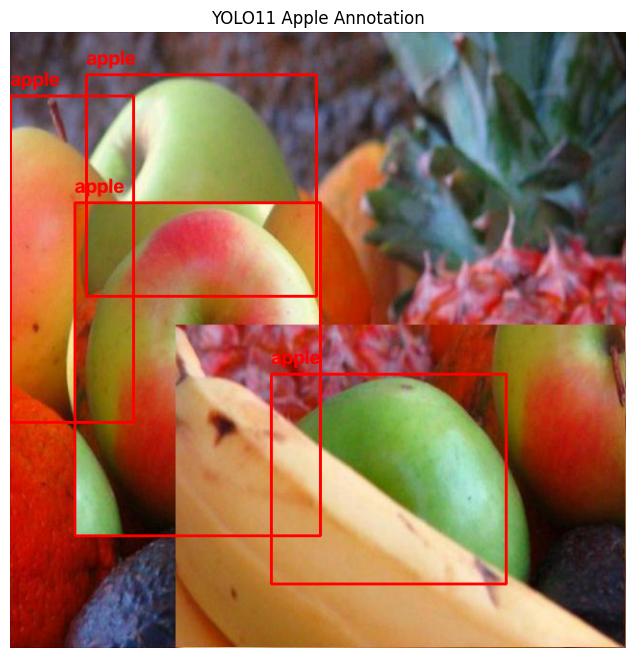

Image: C:\major-project\model\yolo11_dataset\images\train\b1ce6250dad71e9e_jpg.rf.87870d483fd87825a1c1fefbd2b2163b.jpg
Label: C:\major-project\model\yolo11_dataset\labels\train\b1ce6250dad71e9e_jpg.rf.87870d483fd87825a1c1fefbd2b2163b.txt


In [22]:
# ============================================================
# CELL 22 - VISUALIZE APPLE ANNOTATION
# ============================================================

train_images = list(
    (
        YOLO_DATASET
        / "images"
        / "train"
    ).glob("*")
)

if not train_images:

    raise RuntimeError(
        "No training images found.\n"
        "Run Cells 15, 16, 16A and 17 again."
    )

sample_image = random.choice(
    train_images
)

label_file = (
    YOLO_DATASET
    / "labels"
    / "train"
    / f"{sample_image.stem}.txt"
)

if not label_file.exists():

    raise FileNotFoundError(
        f"Label not found:\n{label_file}"
    )

image = cv2.imread(
    str(sample_image)
)

if image is None:

    raise RuntimeError(
        f"Could not read image:\n{sample_image}"
    )

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

height, width = image.shape[:2]

with open(
    label_file,
    "r",
    encoding="utf-8"
) as f:

    lines = f.readlines()

for line in lines:

    parts = line.strip().split()

    if len(parts) != 5:

        continue

    class_id = int(parts[0])

    center_x = float(parts[1])
    center_y = float(parts[2])
    box_width = float(parts[3])
    box_height = float(parts[4])

    x1 = int(
        (center_x - box_width / 2)
        * width
    )

    y1 = int(
        (center_y - box_height / 2)
        * height
    )

    x2 = int(
        (center_x + box_width / 2)
        * width
    )

    y2 = int(
        (center_y + box_height / 2)
        * height
    )

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image,
        "apple",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(
    figsize=(10, 8)
)

plt.imshow(image)

plt.axis("off")

plt.title(
    "YOLO11 Apple Annotation"
)

plt.show()

print(
    "Image:",
    sample_image
)

print(
    "Label:",
    label_file
)

In [23]:
# ============================================================
# CELL 23 - CHECK COMPUTE DEVICE
# ============================================================

import torch

print("PyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():

    print("\nGPU:")
    print(torch.cuda.get_device_name(0))

else:

    print("\nCUDA GPU is NOT available.")
    print("YOLO training will use CPU.")

PyTorch version:
2.9.0+cpu

CUDA available:
False

CUDA GPU is NOT available.
YOLO training will use CPU.


In [24]:
# ============================================================
# CELL 24 - LOAD YOLO11
# ============================================================

YOLO_MODEL_PATH = (
    YOLO_ROOT
    / "yolo11n.pt"
)

print(
    "Model path:",
    YOLO_MODEL_PATH
)

print(
    "Model exists:",
    YOLO_MODEL_PATH.exists()
)

Model path: C:\major-project\model\yolo11\yolo11n.pt
Model exists: False


In [40]:
# ============================================================
# CELL 24 - YOLO11 MODEL PATHS
# ============================================================

from pathlib import Path

YOLO_ROOT = Path(
    r"C:\major-project\model\yolo11"
)

# Base YOLO11 model
BASE_MODEL_PATH = YOLO_ROOT / "yolo11n.pt"

# Trained YOLO11 model
TRAINED_MODEL_PATH = (
    YOLO_ROOT
    / "runs"
    / "apple_detection_test"
    / "weights"
    / "best.pt"
)

print("YOLO root:")
print(YOLO_ROOT)

print("\nBase model:")
print(BASE_MODEL_PATH)

print("Base model exists:", BASE_MODEL_PATH.exists())

print("\nTrained model:")
print(TRAINED_MODEL_PATH)

print("Trained model exists:", TRAINED_MODEL_PATH.exists())

YOLO root:
C:\major-project\model\yolo11

Base model:
C:\major-project\model\yolo11\yolo11n.pt
Base model exists: True

Trained model:
C:\major-project\model\yolo11\runs\apple_detection_test\weights\best.pt
Trained model exists: True


In [41]:
# ============================================================
# CELL 25 - LOAD TRAINED YOLO11 MODEL
# ============================================================

from ultralytics import YOLO

if not TRAINED_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Trained model not found:\n{TRAINED_MODEL_PATH}"
    )

test_model = YOLO(
    str(TRAINED_MODEL_PATH)
)

print("Trained YOLO11 model loaded successfully.")

Trained YOLO11 model loaded successfully.


In [42]:
# ============================================================
# CELL 26 - TEST ONE IMAGE
# ============================================================

import random

test_images = list(
    (
        YOLO_DATASET / "images" / "test"
    ).glob("*")
)

print("Test images:", len(test_images))

if len(test_images) == 0:
    raise RuntimeError("No test images found.")

test_image = random.choice(test_images)

print("Testing image:")
print(test_image)

prediction = test_model.predict(
    source=str(test_image),
    conf=0.25,
    device="cpu",
    save=True
)

print("\nPrediction completed.")

Test images: 113
Testing image:
C:\major-project\model\yolo11_dataset\images\test\aeb74d9188146556_jpg.rf.ef3d4c510d52bbda634844f5adb4394a.jpg



image 1/1 C:\major-project\model\yolo11_dataset\images\test\aeb74d9188146556_jpg.rf.ef3d4c510d52bbda634844f5adb4394a.jpg: 640x640 3 apples, 82.2ms
Speed: 2.6ms preprocess, 82.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\kiran\runs\detect\predict

Prediction completed.


In [44]:
# ============================================================
# CELL 26 - TEST ONE IMAGE
# ============================================================

import random

test_images = list(
    (
        YOLO_DATASET / "images" / "test"
    ).glob("*")
)

print("Test images:", len(test_images))

if len(test_images) == 0:
    raise RuntimeError("No test images found.")

test_image = random.choice(test_images)

print("Testing image:")
print(test_image)

prediction = test_model.predict(
    source=str(test_image),
    conf=0.25,
    device="cpu",
    save=True
)

print("\nPrediction completed.")

Test images: 113
Testing image:
C:\major-project\model\yolo11_dataset\images\test\942457b85a0729da_jpg.rf.9111b7ccdb6aecd44287846f1c0e1f27.jpg

image 1/1 C:\major-project\model\yolo11_dataset\images\test\942457b85a0729da_jpg.rf.9111b7ccdb6aecd44287846f1c0e1f27.jpg: 640x640 1 apple, 102.1ms
Speed: 2.7ms preprocess, 102.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\kiran\runs\detect\predict

Prediction completed.


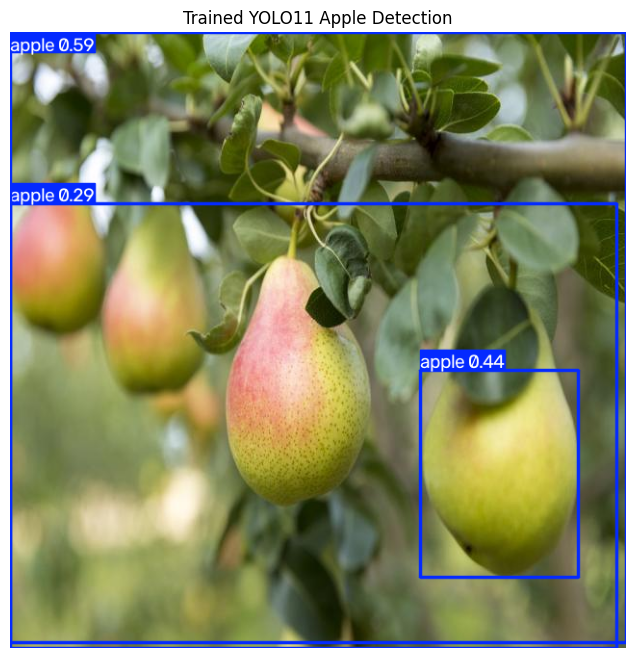

In [43]:
# ============================================================
# CELL 27 - DISPLAY YOLO11 RESULT
# ============================================================

import cv2
import matplotlib.pyplot as plt

result = prediction[0]

annotated_image = result.plot()

annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Trained YOLO11 Apple Detection")
plt.show()

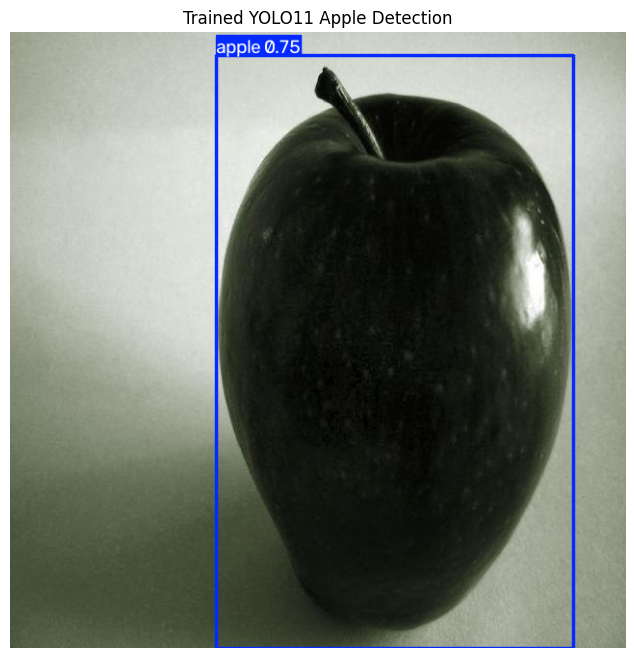

In [45]:
# ============================================================
# CELL 27 - DISPLAY YOLO11 RESULT
# ============================================================

import cv2
import matplotlib.pyplot as plt

result = prediction[0]

annotated_image = result.plot()

annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Trained YOLO11 Apple Detection")
plt.show()

In [35]:
# ============================================================
# CELL 28 - YOLO11 TEST TRAINING
# ============================================================

results = model.train(
    data=str(DATA_YAML),
    epochs=5,
    imgsz=640,
    batch=4,
    project=str(YOLO_RUNS),
    name="apple_detection_test",
    device="cpu",
    workers=0,
    patience=3,
    verbose=True
)

print("\n5-epoch test training completed.")

c:\Users\kiran\miniconda3\envs\venv_rating\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.5.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\major-project\model\yolo11_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\major-project\model\yolo11\yolo11n.pt, momentum=0.937, mosaic=1.0, 

In [46]:
# ============================================================
# CELL 28 - PREDICTION DETAILS
# ============================================================

result = prediction[0]

print("Number of detections:", len(result.boxes))

if len(result.boxes) > 0:

    for i, box in enumerate(result.boxes):

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            f"Detection {i + 1}: "
            f"class={class_id}, "
            f"confidence={confidence:.4f}"
        )

else:

    print("No apple detected.")

Number of detections: 1
Detection 1: class=0, confidence=0.7455


In [36]:
# ============================================================
# CELL 29 - VALIDATE TEST MODEL
# ============================================================

metrics = model.val(
    data=str(DATA_YAML),
    imgsz=640,
    batch=4,
    device="cpu"
)

print("\nValidation completed.")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 541.7321.4 MB/s, size: 47.3 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\val.cache... 188 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 188/188  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 4.2it/s 11.2s0.2s
                   all        188        557      0.621      0.452      0.494      0.322
Speed: 0.6ms preprocess, 53.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\kiran\runs\detect\val

Validation completed.


In [37]:
# ============================================================
# CELL 30 - PRINT YOLO METRICS
# ============================================================

print("YOLO11 validation metrics:")
print(metrics)

try:
    print("\nmAP50:", metrics.box.map50)
    print("mAP50-95:", metrics.box.map)
except Exception as e:
    print("Could not directly read metrics:", e)

YOLO11 validation metrics:
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F99C2DB130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,   

In [39]:
# ============================================================
# CELL 31 - RUN APPLE DETECTION
# ============================================================

test_images = list(
    (
        YOLO_DATASET
        / "images"
        / "test"
    ).glob("*")
)

test_image = random.choice(
    test_images
)

print(
    "Testing image:"
)

print(test_image)

prediction = test_model.predict(
    source=str(test_image),
    conf=0.25,
    save=True,
    device="cpu"
)

print(
    "Prediction completed."
)

Testing image:
C:\major-project\model\yolo11_dataset\images\test\75bf4fe9b26565e9_jpg.rf.37af842a553d12b03fdba8222cd3618b.jpg


NameError: name 'test_model' is not defined

In [ ]:
# ============================================================
# CELL 32 - DISPLAY DETECTION
# ============================================================

result = prediction[0]

annotated = result.plot()

annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLO11 Apple Detection")
plt.show()

In [ ]:
# ============================================================
# CELL 33 - DETECTION RESULTS
# ============================================================

boxes = result.boxes

print(
    "Number of detected objects:",
    len(boxes)
)

for i, box in enumerate(boxes):

    confidence = float(
        box.conf[0]
    )

    class_id = int(
        box.cls[0]
    )

    print(
        f"Detection {i + 1}: "
        f"class={class_id}, "
        f"name=apple, "
        f"confidence={confidence:.4f}"
    )

In [ ]:
# ============================================================
# CELL 34 - TEST MULTIPLE IMAGES
# ============================================================

sample_images = random.sample(
    test_images,
    min(10, len(test_images))
)

predictions = test_model.predict(
    source=[
        str(image)
        for image in sample_images
    ],
    conf=0.25,
    device="cpu"
)

print(
    "Images tested:",
    len(predictions)
)

for i, result in enumerate(predictions):

    print(
        f"Image {i + 1}: "
        f"{len(result.boxes)} apple detections"
    )

In [ ]:
# ============================================================
# CELL 35 - FINAL YOLO11 TRAINING
# ============================================================

final_model = YOLO(
    str(YOLO_MODEL_PATH)
)

final_results = final_model.train(

    data=str(DATA_YAML),

    epochs=50,

    imgsz=640,

    batch=4,

    project=str(YOLO_RUNS),

    name="apple_detection_final",

    device="cpu",

    workers=0,

    patience=10,

    save=True,

    plots=True,

    verbose=True
)

In [ ]:
# ============================================================
# CELL 35 - FINAL YOLO11 TRAINING
# ============================================================

final_model = YOLO(
    str(YOLO_MODEL_PATH)
)

final_results = final_model.train(

    data=str(DATA_YAML),

    epochs=50,

    imgsz=640,

    batch=4,

    project=str(YOLO_RUNS),

    name="apple_detection_final",

    device="cpu",

    workers=0,

    patience=10,

    save=True,

    plots=True,

    verbose=True
)

In [ ]:
# ============================================================
# CELL 37 - FINAL VALIDATION
# ============================================================

final_metrics = final_model.val(

    data=str(DATA_YAML),

    split="val",

    imgsz=640,

    batch=4,

    device="cpu"
)

print(
    "Precision:",
    final_metrics.box.mp
)

print(
    "Recall:",
    final_metrics.box.mr
)

print(
    "mAP50:",
    final_metrics.box.map50
)

print(
    "mAP50-95:",
    final_metrics.box.map
)

In [ ]:
# ============================================================
# CELL 38 - FINAL TEST SET EVALUATION
# ============================================================

test_metrics = final_model.val(

    data=str(DATA_YAML),

    split="test",

    imgsz=640,

    batch=4,

    device="cpu"
)

print(
    "TEST PRECISION:",
    test_metrics.box.mp
)

print(
    "TEST RECALL:",
    test_metrics.box.mr
)

print(
    "TEST mAP50:",
    test_metrics.box.map50
)

print(
    "TEST mAP50-95:",
    test_metrics.box.map
)

In [ ]:
# ============================================================
# CELL 39 - SAVE FINAL METRICS
# ============================================================

metrics_file = (
    YOLO_ROOT
    / "apple_detection_metrics.txt"
)

with open(
    metrics_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "YOLO11 APPLE DETECTION MODEL\n"
    )

    f.write(
        "============================\n\n"
    )

    f.write(
        f"Precision: "
        f"{test_metrics.box.mp:.6f}\n"
    )

    f.write(
        f"Recall: "
        f"{test_metrics.box.mr:.6f}\n"
    )

    f.write(
        f"mAP50: "
        f"{test_metrics.box.map50:.6f}\n"
    )

    f.write(
        f"mAP50-95: "
        f"{test_metrics.box.map:.6f}\n"
    )

print(
    "Metrics saved to:"
)

print(
    metrics_file
)

In [ ]:
# ============================================================
# CELL 40 - COPY MODEL TO API
# ============================================================

API_YOLO_DIR = (
    PROJECT_ROOT
    / "api"
    / "models"
    / "yolo11"
)

API_YOLO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PRODUCTION_MODEL = (
    API_YOLO_DIR
    / "best.pt"
)

shutil.copy2(
    FINAL_BEST_MODEL,
    PRODUCTION_MODEL
)

print(
    "Production model copied successfully:"
)

print(
    PRODUCTION_MODEL
)

print(
    "\nSize:",
    PRODUCTION_MODEL.stat().st_size / (1024 * 1024),
    "MB"
)

In [ ]:
# ============================================================
# CELL 41 - VERIFY PRODUCTION MODEL
# ============================================================

assert PRODUCTION_MODEL.exists()

production_model = YOLO(
    str(PRODUCTION_MODEL)
)

print(
    "Production YOLO11 model loaded successfully."
)

production_model.info()

In [ ]:
# ============================================================
# CELL 42 - PRODUCTION MODEL TEST
# ============================================================

sample_image = random.choice(
    test_images
)

production_result = production_model.predict(
    source=str(sample_image),
    conf=0.25,
    device="cpu"
)

annotated = production_result[0].plot()

annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))

plt.imshow(
    annotated
)

plt.axis("off")

plt.title(
    "Production YOLO11 Apple Detector"
)

plt.show()

In [47]:
from pathlib import Path

TRAINED_MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_test\weights\best.pt"
)

print("Model exists:", TRAINED_MODEL_PATH.exists())
print("Model:", TRAINED_MODEL_PATH)

Model exists: True
Model: C:\major-project\model\yolo11\runs\apple_detection_test\weights\best.pt


In [50]:
from pathlib import Path

# ============================================================
# YOLO11 SINGLE IMAGE INFERENCE TEST
# ============================================================

IMAGE_DIR = Path(
    r"C:\major-project\model\yolo11_dataset\images"
)

print("Image directory exists:", IMAGE_DIR.exists())

if not IMAGE_DIR.exists():
    raise FileNotFoundError(
        f"Image directory not found:\n{IMAGE_DIR}"
    )

# Find image files
image_files = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_files.extend(IMAGE_DIR.rglob(ext))

print("Images found:", len(image_files))

if len(image_files) == 0:
    raise FileNotFoundError(
        f"No images found inside:\n{IMAGE_DIR}"
    )

TEST_IMAGE = image_files[0]

print("\nTesting image:")
print(TEST_IMAGE)

# Run YOLO inference
results = model.predict(
    source=str(TEST_IMAGE),
    conf=0.25,
    save=True,
    verbose=True
)

print("\nInference completed successfully.")

Image directory exists: True
Images found: 3730

Testing image:
C:\major-project\model\yolo11_dataset\images\test\000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg

image 1/1 C:\major-project\model\yolo11_dataset\images\test\000d9c59687b509b_jpg.rf.c338360b3dfe1953a5d266ee861d7e79.jpg: 640x640 2 apples, 90.9ms
Speed: 2.6ms preprocess, 90.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\kiran\runs\detect\predict-2

Inference completed successfully.


In [51]:
# ============================================================
# YOLO11 DETECTION DETAILS
# ============================================================

result = results[0]

print("Number of detections:", len(result.boxes))
print()

for i, box in enumerate(result.boxes, start=1):

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    print(f"Detection {i}")
    print(f"  Class       : {model.names[class_id]}")
    print(f"  Confidence  : {confidence:.4f}")
    print(f"  Bounding box: ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
    print()

Number of detections: 2

Detection 1
  Class       : apple
  Confidence  : 0.5347
  Bounding box: (228.5, 240.0, 558.6, 555.8)

Detection 2
  Class       : apple
  Confidence  : 0.3719
  Bounding box: (0.4, 1.0, 245.0, 242.7)



In [52]:
# ============================================================
# YOLO11 DETECTION SUMMARY
# ============================================================

detections = []

for box in result.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    detections.append({
        "class": model.names[class_id],
        "confidence": confidence
    })

print("YOLO11 Detection Summary")
print("=" * 50)

print("Total objects :", len(detections))

for detection in detections:
    print(
        f"{detection['class']} "
        f"(confidence={detection['confidence']:.2%})"
    )

if detections:
    average_confidence = sum(
        d["confidence"] for d in detections
    ) / len(detections)

    print()
    print(
        f"Average confidence: "
        f"{average_confidence:.2%}"
    )

YOLO11 Detection Summary
Total objects : 2
apple (confidence=53.47%)
apple (confidence=37.19%)

Average confidence: 45.33%


In [53]:
# ============================================================
# YOLO11 FINAL EVALUATION + VISUALIZATION
# ============================================================

from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained model
model = YOLO(
    r"C:\major-project\model\yolo11\runs\apple_detection_test\weights\best.pt"
)

# Evaluate on TEST dataset
metrics = model.val(
    data=r"C:\major-project\model\yolo11_dataset\data.yaml",
    split="test",
    imgsz=640,
    batch=4,
    device="cpu",
    plots=True
)

# Metrics
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print("=" * 60)
print("YOLO11 APPLE DETECTION PERFORMANCE")
print("=" * 60)

print(f"Precision       : {precision:.4f}  ({precision * 100:.2f}%)")
print(f"Recall          : {recall:.4f}  ({recall * 100:.2f}%)")
print(f"mAP@50          : {map50:.4f}  ({map50 * 100:.2f}%)")
print(f"mAP@50-95       : {map5095:.4f}  ({map5095 * 100:.2f}%)")

print("=" * 60)
print(f"Detection Score : {map50 * 100:.2f}%")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 109.2227.7 MB/s, size: 59.3 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\test... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113 373.6it/s 0.3s2s
val: New cache created: C:\major-project\model\yolo11_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 4.2it/s 7.0s0.2s
                   all        113        422      0.485      0.393      0.397      0.281
Speed: 0.7ms preprocess, 55.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\kiran\runs\detect\val-2
YOLO11 APPLE DETECTION PERFORMANCE
Precision       : 0.4850  (48.50%)
Recall          : 0.3934  (39.34%)
mAP@50          : 0.3967  (39.67%)
mAP@50-95       : 0.2809  (

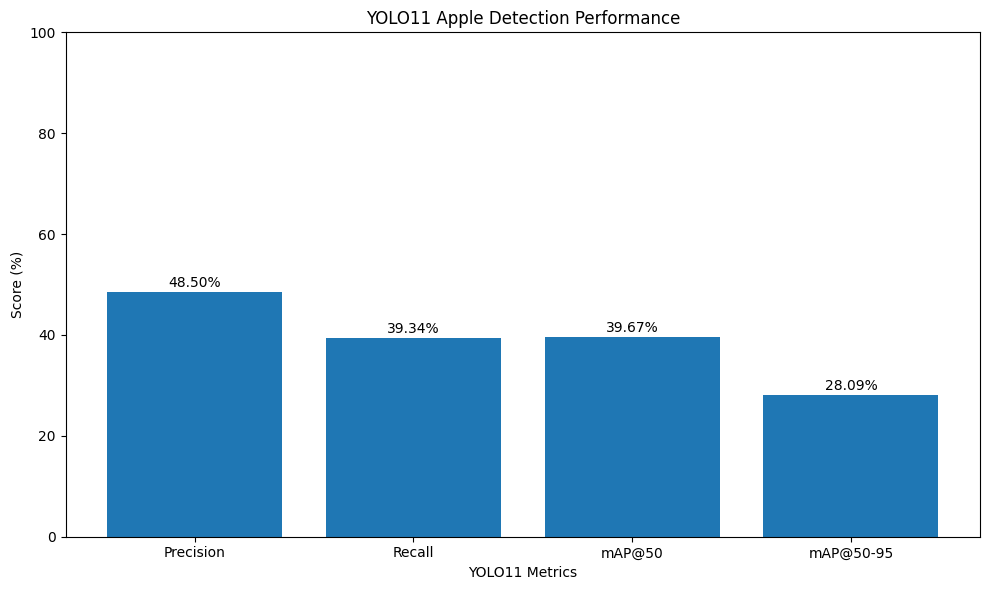

In [54]:
# ============================================================
# YOLO11 PERFORMANCE VISUALIZATION
# ============================================================

metric_names = [
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50-95"
]

metric_values = [
    precision * 100,
    recall * 100,
    map50 * 100,
    map5095 * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.ylabel("Score (%)")
plt.xlabel("YOLO11 Metrics")
plt.title("YOLO11 Apple Detection Performance")
plt.ylim(0, 100)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [55]:
from pathlib import Path
import yaml

DATASET_ROOT = Path(
    r"C:\major-project\model\yolo11_dataset"
)

DATA_YAML = DATASET_ROOT / "data.yaml"

print("Dataset:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())
print("data.yaml exists:", DATA_YAML.exists())

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

print("\nDataset configuration:")
print(data)

for split in ["train", "val", "test"]:
    image_dir = DATASET_ROOT / "images" / split
    label_dir = DATASET_ROOT / "labels" / split

    print(f"\n{split.upper()}")
    print("Images:", image_dir.exists())
    print("Labels:", label_dir.exists())

    if image_dir.exists():
        images = list(image_dir.glob("*"))
        print("Image count:", len(images))

    if label_dir.exists():
        labels = list(label_dir.glob("*.txt"))
        print("Label count:", len(labels))

Dataset: C:\major-project\model\yolo11_dataset
Dataset exists: True
data.yaml exists: True

Dataset configuration:
{'path': 'C:\\major-project\\model\\yolo11_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'apple'}}

TRAIN
Images: True
Labels: True
Image count: 1564
Label count: 1564

VAL
Images: True
Labels: True
Image count: 188
Label count: 188

TEST
Images: True
Labels: True
Image count: 113
Label count: 113


In [56]:
from ultralytics import YOLO

model = YOLO(
    r"C:\major-project\model\yolo11\yolo11n.pt"
)

results = model.train(
    data=r"C:\major-project\model\yolo11_dataset\data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=20,
    device="cpu",

    project=r"C:\major-project\model\yolo11\runs",
    name="apple_detection_final_v2",

    pretrained=True,
    cache=False,
    plots=True,
    save=True,
    save_period=10
)

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\major-project\model\yolo11_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\major-project\model\yolo11\yolo11n.pt, momentum=0.937, mosaic=1.0

In [57]:
import json
from pathlib import Path
from copy import deepcopy

src = Path("/mnt/data/yolo11_training.ipynb")
dst = Path("/mnt/data/yolo11_training_final_v2.ipynb")

with src.open("r", encoding="utf-8") as f:
    nb = json.load(f)

new_cells = [
    {
        "cell_type": "markdown",
        "metadata": {},
        "source": [
            "# YOLO11 FINAL TRAINING V2\n",
            "\n",
            "This section starts a fresh final training run using the existing Apple-only YOLO dataset. Previous experiments are kept unchanged."
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - VERIFY DATASET AND BASE MODEL\n",
            "# ============================================================\n",
            "\n",
            "from pathlib import Path\n",
            "from ultralytics import YOLO\n",
            "\n",
            "PROJECT_ROOT = Path(r\"C:\\major-project\")\n",
            "YOLO_ROOT = PROJECT_ROOT / \"model\" / \"yolo11\"\n",
            "YOLO_DATASET = PROJECT_ROOT / \"model\" / \"yolo11_dataset\"\n",
            "DATA_YAML = YOLO_DATASET / \"data.yaml\"\n",
            "BASE_MODEL = YOLO_ROOT / \"yolo11n.pt\"\n",
            "\n",
            "print(\"Dataset:\", YOLO_DATASET)\n",
            "print(\"Dataset exists:\", YOLO_DATASET.exists())\n",
            "print(\"data.yaml exists:\", DATA_YAML.exists())\n",
            "print(\"Base YOLO11 model:\", BASE_MODEL)\n",
            "print(\"Base model exists:\", BASE_MODEL.exists())\n",
            "\n",
            "assert YOLO_DATASET.exists(), \"YOLO dataset not found.\"\n",
            "assert DATA_YAML.exists(), \"data.yaml not found.\"\n",
            "assert BASE_MODEL.exists(), \"yolo11n.pt not found.\"\n            "
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - VERIFY TRAIN / VAL / TEST COUNTS\n",
            "# ============================================================\n",
            "\n",
            "for split in [\"train\", \"val\", \"test\"]:\n",
            "    image_dir = YOLO_DATASET / \"images\" / split\n",
            "    label_dir = YOLO_DATASET / \"labels\" / split\n",
            "\n",
            "    image_count = sum(1 for p in image_dir.iterdir() if p.is_file())\n",
            "    label_count = len(list(label_dir.glob(\"*.txt\")))\n",
            "\n",
            "    print(f\"{split.upper():5} -> {image_count} images | {label_count} labels\")\n",
            "\n",
            "    assert image_count == label_count, (\n",
            "        f\"{split}: image/label count mismatch\"\n",
            "    )\n",
            "\n",
            "print(\"\\nDataset verification passed.\")"
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - TRAIN YOLO11\n",
            "# ============================================================\n",
            "\n",
            "model = YOLO(str(BASE_MODEL))\n",
            "\n",
            "training_results = model.train(\n",
            "    data=str(DATA_YAML),\n",
            "    epochs=100,\n",
            "    imgsz=640,\n",
            "    batch=4,\n",
            "    patience=20,\n",
            "    device=\"cpu\",\n",
            "    workers=0,\n",
            "    pretrained=True,\n",
            "    cache=False,\n",
            "    plots=True,\n",
            "    save=True,\n",
            "    save_period=10,\n",
            "    project=str(YOLO_ROOT / \"runs\"),\n",
            "    name=\"apple_detection_final_v2\",\n",
            "    exist_ok=False\n",
            ")\n",
            "\n",
            "print(\"\\nFINAL V2 TRAINING COMPLETED.\")"
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - LOCATE BEST MODEL\n",
            "# ============================================================\n",
            "\n",
            "FINAL_RUN = YOLO_ROOT / \"runs\" / \"apple_detection_final_v2\"\n",
            "FINAL_BEST = FINAL_RUN / \"weights\" / \"best.pt\"\n",
            "FINAL_LAST = FINAL_RUN / \"weights\" / \"last.pt\"\n",
            "\n",
            "print(\"Run directory:\", FINAL_RUN)\n",
            "print(\"best.pt exists:\", FINAL_BEST.exists())\n",
            "print(\"last.pt exists:\", FINAL_LAST.exists())\n",
            "\n",
            "assert FINAL_BEST.exists(), \"best.pt was not created.\"\n            "
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - TEST SET EVALUATION\n",
            "# ============================================================\n",
            "\n",
            "final_model = YOLO(str(FINAL_BEST))\n\n",
            "metrics = final_model.val(\n",
            "    data=str(DATA_YAML),\n",
            "    split=\"test\",\n",
            "    imgsz=640,\n",
            "    batch=4,\n",
            "    device=\"cpu\",\n",
            "    workers=0,\n",
            "    plots=True,\n",
            "    project=str(YOLO_ROOT / \"runs\"),\n",
            "    name=\"apple_detection_final_v2_test\",\n",
            "    exist_ok=True\n",
            ")\n\n",
            "precision = float(metrics.box.mp)\n",
            "recall = float(metrics.box.mr)\n",
            "map50 = float(metrics.box.map50)\n",
            "map5095 = float(metrics.box.map)\n\n",
            "print(\"=\" * 60)\n",
            "print(\"YOLO11 FINAL V2 TEST PERFORMANCE\")\n",
            "print(\"=\" * 60)\n",
            "print(f\"Precision   : {precision * 100:.2f}%\")\n",
            "print(f\"Recall      : {recall * 100:.2f}%\")\n",
            "print(f\"mAP@50      : {map50 * 100:.2f}%\")\n",
            "print(f\"mAP@50-95   : {map5095 * 100:.2f}%\")\n",
            "print(\"=\" * 60)\n"
        ]
    },
    {
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": [
            "# ============================================================\n",
            "# FINAL V2 - PERFORMANCE VISUALIZATION\n",
            "# ============================================================\n",
            "\n",
            "import matplotlib.pyplot as plt\n\n",
            "metric_names = [\n",
            "    \"Precision\",\n",
            "    \"Recall\",\n",
            "    \"mAP@50\",\n",
            "    \"mAP@50-95\"\n",
            "]\n\n",
            "metric_values = [\n",
            "    precision * 100,\n",
            "    recall * 100,\n",
            "    map50 * 100,\n",
            "    map5095 * 100\n",
            "]\n\n",
            "plt.figure(figsize=(10, 6))\n",
            "bars = plt.bar(metric_names, metric_values)\n",
            "plt.title(\"YOLO11 Apple Detection - Final V2 Performance\")\n",
            "plt.ylabel(\"Score (%)\")\n",
            "plt.ylim(0, 100)\n\n",
            "for bar, value in zip(bars, metric_values):\n",
            "    plt.text(\n",
            "        bar.get_x() + bar.get_width() / 2,\n",
            "        value + 1,\n",
            "        f\"{value:.2f}%\",\n",
            "        ha=\"center\"\n",
            "    )\n\n",
            "plt.tight_layout()\n",
            "plt.show()\n"
        ]
    }
]

nb2 = deepcopy(nb)
nb2.setdefault("cells", []).extend(new_cells)

with dst.open("w", encoding="utf-8") as f:
    json.dump(nb2, f, ensure_ascii=False, indent=1)

print(f"Created: {dst}")
print(f"Original cells: {len(nb.get('cells', []))}")
print(f"New cells added: {len(new_cells)}")
print(f"Total cells: {len(nb2.get('cells', []))}")


FileNotFoundError: [Errno 2] No such file or directory: '\\mnt\\data\\yolo11_training.ipynb'

In [58]:
from pathlib import Path

BEST_MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt"
)

LAST_MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\last.pt"
)

print("Best model exists:", BEST_MODEL_PATH.exists())
print("Last model exists:", LAST_MODEL_PATH.exists())

print("\nBest model path:")
print(BEST_MODEL_PATH)

print("\nLast model path:")
print(LAST_MODEL_PATH)

Best model exists: True
Last model exists: True

Best model path:
C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt

Last model path:
C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\last.pt


In [59]:
from ultralytics import YOLO

best_model = YOLO(str(BEST_MODEL_PATH))

metrics = best_model.val(
    data=r"C:\major-project\model\yolo11_dataset\data.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device="cpu",
    plots=True
)

print("Evaluation completed successfully.")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 593.8141.9 MB/s, size: 62.7 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\test.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.3it/s 6.4s0.4s
                   all        113        422      0.488      0.437      0.442      0.318
Speed: 0.7ms preprocess, 50.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Users\kiran\runs\detect\val-3
Evaluation completed successfully.


In [60]:
print("=" * 50)
print("FINAL YOLO11 MODEL PERFORMANCE")
print("=" * 50)

print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print(f"mAP@50:     {metrics.box.map50:.4f}")
print(f"mAP@50-95:  {metrics.box.map:.4f}")

FINAL YOLO11 MODEL PERFORMANCE
Precision:  0.4884
Recall:     0.4366
mAP@50:     0.4424
mAP@50-95:  0.3178


In [61]:
from pathlib import Path

MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt"
)

DATA_YAML = Path(
    r"C:\major-project\model\yolo11_dataset\data.yaml"
)

TEST_IMAGES = Path(
    r"C:\major-project\model\yolo11_dataset\images\test"
)

print("MODEL CHECK")
print("Model exists:", MODEL_PATH.exists())
print("Model path:", MODEL_PATH)

print("\nDATASET CHECK")
print("data.yaml exists:", DATA_YAML.exists())
print("Test images exist:", TEST_IMAGES.exists())

if TEST_IMAGES.exists():
    print("Test images:", len(list(TEST_IMAGES.glob("*.*"))))

MODEL CHECK
Model exists: True
Model path: C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt

DATASET CHECK
data.yaml exists: True
Test images exist: True
Test images: 113


In [62]:
from ultralytics import YOLO

# Load the best trained model
best_model = YOLO(str(MODEL_PATH))

# Evaluate on the TEST dataset
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=8,
    project=r"C:\major-project\model\yolo11\evaluation",
    name="test_evaluation",
    exist_ok=True
)

print("\n" + "=" * 60)
print("FINAL TEST EVALUATION RESULTS")
print("=" * 60)

print(f"Precision:  {test_results.box.mp:.4f} ({test_results.box.mp * 100:.2f}%)")
print(f"Recall:     {test_results.box.mr:.4f} ({test_results.box.mr * 100:.2f}%)")
print(f"mAP@50:     {test_results.box.map50:.4f} ({test_results.box.map50 * 100:.2f}%)")
print(f"mAP@50-95:  {test_results.box.map:.4f} ({test_results.box.map * 100:.2f}%)")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 649.9216.1 MB/s, size: 58.0 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\test.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.1it/s 7.2s0.5s
                   all        113        422      0.488      0.437      0.442      0.318
Speed: 0.7ms preprocess, 55.1ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\major-project\model\yolo11\evaluation\test_evaluation

FINAL TEST EVALUATION RESULTS
Precision:  0.4884 (48.84%)
Recall:     0.4366 (43.66%)
mAP@50:     0.4424 (44.24%)
mAP@50-95:  0.3178 (31.78%)


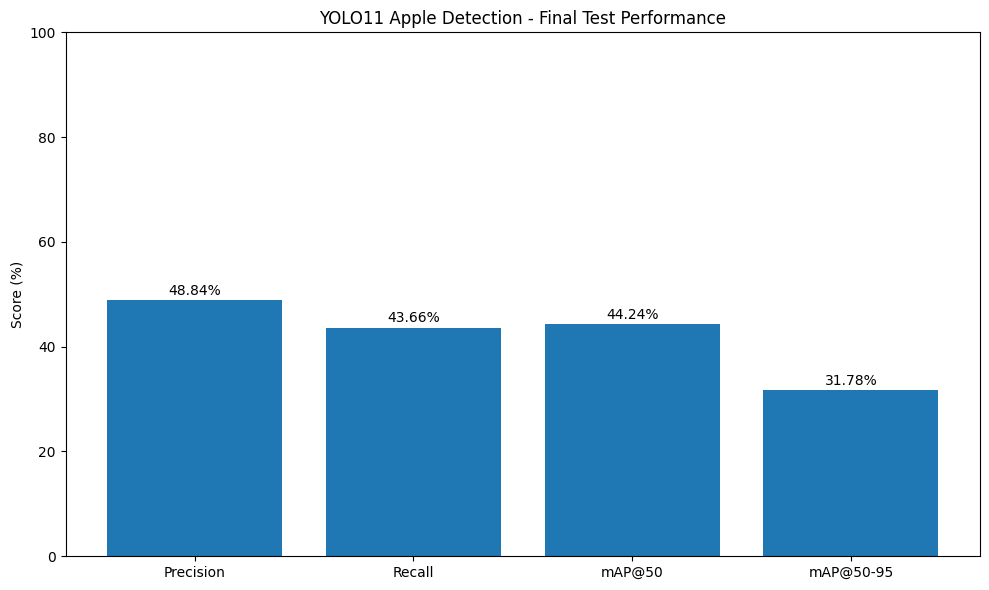

In [63]:
import matplotlib.pyplot as plt

metrics_names = [
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50-95"
]

metrics_values = [
    test_results.box.mp * 100,
    test_results.box.mr * 100,
    test_results.box.map50 * 100,
    test_results.box.map * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(metrics_names, metrics_values)

plt.title("YOLO11 Apple Detection - Final Test Performance")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, metrics_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [64]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=8,
    ...
)

SyntaxError: positional argument follows keyword argument (3550290777.py, line 7)

In [65]:
from pathlib import Path
from ultralytics import YOLO

# Path to the best trained model
BEST_MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt"
)

# Path to dataset configuration
DATA_YAML = Path(
    r"C:\major-project\model\yolo11\yolo11_dataset\data.yaml"
)

print("Best model exists:", BEST_MODEL_PATH.exists())
print("Dataset YAML exists:", DATA_YAML.exists())

# Load the best model
best_model = YOLO(str(BEST_MODEL_PATH))

print("\nBest model loaded successfully!")

Best model exists: True
Dataset YAML exists: False

Best model loaded successfully!


In [66]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640
)

print("\nEvaluation completed successfully!")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


FileNotFoundError: 'C:\major-project\model\yolo11\yolo11_dataset\data.yaml' does not exist

In [67]:
from pathlib import Path
from ultralytics import YOLO

EPOCH70_MODEL_PATH = Path(
    r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\epoch70.pt"
)

DATA_YAML = Path(
    r"C:\major-project\model\yolo11\yolo11_dataset\data.yaml"
)

print("Epoch 70 model exists:", EPOCH70_MODEL_PATH.exists())
print("Dataset YAML exists:", DATA_YAML.exists())

epoch70_model = YOLO(str(EPOCH70_MODEL_PATH))

print("\nEpoch 70 model loaded successfully!")

Epoch 70 model exists: True
Dataset YAML exists: False

Epoch 70 model loaded successfully!


In [68]:
test_results_70 = epoch70_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640
)

print("\nEpoch 70 evaluation completed!")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs


FileNotFoundError: 'C:\major-project\model\yolo11\yolo11_dataset\data.yaml' does not exist

In [69]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\major-project")

yaml_files = list(PROJECT_ROOT.rglob("data.yaml"))

print("Found data.yaml files:")
for file in yaml_files:
    print(file)

Found data.yaml files:
C:\major-project\model\fruit_detection_source\data.yaml
C:\major-project\model\yolo11\Fruits-detection\data.yaml
C:\major-project\model\yolo11_dataset\data.yaml


In [70]:
from pathlib import Path

DATA_YAML_70 = Path(r"C:\major-project\model\yolo11_dataset\data.yaml")

print("Dataset YAML path:", DATA_YAML_70)
print("Dataset YAML exists:", DATA_YAML_70.exists())

assert DATA_YAML_70.exists(), "data.yaml was not found!"

Dataset YAML path: C:\major-project\model\yolo11_dataset\data.yaml
Dataset YAML exists: True


In [71]:
test_results_70 = epoch70_model.val(
    data=r"C:\major-project\model\yolo11_dataset\data.yaml",
    split="test",
    imgsz=640,
    batch=8
)

print("\nEpoch 70 model evaluation completed!")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
val: Fast image access  (ping: 0.10.1 ms, read: 193.5175.3 MB/s, size: 35.8 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\test.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.3it/s 6.5s0.5s
                   all        113        422      0.517      0.412      0.437      0.319
Speed: 0.7ms preprocess, 50.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\kiran\runs\detect\val-6

Epoch 70 model evaluation completed!


In [72]:
from ultralytics import YOLO

BEST_MODEL_PATH = r"C:\major-project\model\yolo11\runs\apple_detection_final_v2\weights\best.pt"

best_model = YOLO(BEST_MODEL_PATH)

best_test_results = best_model.val(
    data=r"C:\major-project\model\yolo11_dataset\data.yaml",
    split="test",
    imgsz=640,
    batch=8
)

print("Best model evaluation completed!")

Ultralytics 8.4.126  Python-3.10.18 torch-2.9.0+cpu CPU (12th Gen Intel Core i5-12450HX)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 708.3294.5 MB/s, size: 64.4 KB)
val: Scanning C:\major-project\model\yolo11_dataset\labels\test.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.4it/s 6.2s0.4s
                   all        113        422      0.488      0.437      0.442      0.318
Speed: 0.8ms preprocess, 48.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\kiran\runs\detect\val-7
Best model evaluation completed!
